In [ ]:

# RabTech Academy - Task 03
## Feature Engineering & Preprocessing Pipeline

### Objective
Build a robust and leak-free machine learning preprocessing pipeline using
Scikit-Learn.

### Tasks Performed
- Load a complex tabular dataset
- Handle missing values
- Separate numerical and categorical features
- Scale numerical features
- Apply One-Hot Encoding to categorical features
- Prevent data leakage using train/test splitting
- Build reusable Scikit-Learn Pipelines
- Train a Random Forest model
- Analyze feature importance

In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the Adult Income dataset

from sklearn.datasets import fetch_openml

adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (48842, 15)


In [ ]:
# Display first five rows

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [ ]:
# Check dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 48842
Number of columns: 15


In [ ]:
# Check column names

print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']


In [ ]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64


In [ ]:
# Display columns with missing values

missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

workclass         2799
occupation        2809
native-country     857
dtype: int64


In [ ]:
# Separate features and target

X = df.drop("class", axis=1)
y = df["class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (48842, 14)
Target shape: (48842,)


In [ ]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [ ]:
# Split the data BEFORE performing preprocessing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 39073
Testing samples: 9769


In [ ]:
# Numerical preprocessing pipeline

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical pipeline created successfully!")

Numerical pipeline created successfully!


In [ ]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

print("Categorical pipeline created successfully!")

Categorical pipeline created successfully!


In [ ]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("ColumnTransformer created successfully!")

ColumnTransformer created successfully!


In [ ]:
# Create complete machine learning pipeline

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Complete ML pipeline created successfully!")

Complete ML pipeline created successfully!


In [ ]:
# Train the complete pipeline

model_pipeline.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Make predictions on test data

y_pred = model_pipeline.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
['<=50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '<=50K'
 '<=50K']


In [ ]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 86.02 %


In [ ]:
# Classification report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.64      0.69      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [ ]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6917  514]
 [ 852 1486]]


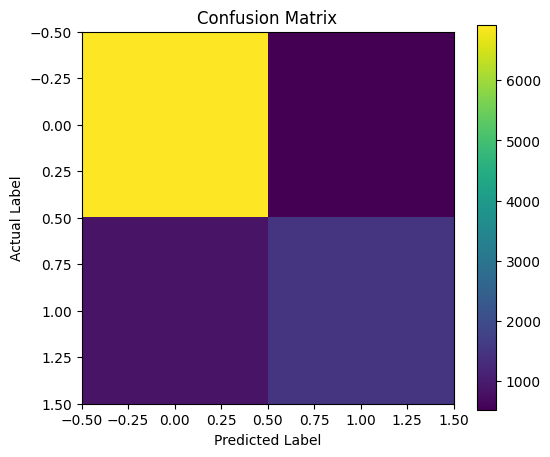

In [ ]:
# Visualize confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.show()

In [ ]:
# Get feature names after preprocessing

feature_names = model_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 processed features:")

print(feature_names[:20])

Number of processed features: 105

First 20 processed features:
['num__age' 'num__fnlwgt' 'num__education-num' 'num__capital-gain'
 'num__capital-loss' 'num__hours-per-week' 'cat__workclass_Federal-gov'
 'cat__workclass_Local-gov' 'cat__workclass_Never-worked'
 'cat__workclass_Private' 'cat__workclass_Self-emp-inc'
 'cat__workclass_Self-emp-not-inc' 'cat__workclass_State-gov'
 'cat__workclass_Without-pay' 'cat__education_10th' 'cat__education_11th'
 'cat__education_12th' 'cat__education_1st-4th' 'cat__education_5th-6th'
 'cat__education_7th-8th']


In [ ]:
# Extract feature importance from Random Forest

importances = model_pipeline.named_steps[
    "classifier"
].feature_importances_

print("Number of importance values:", len(importances))

Number of importance values: 105


In [ ]:
# Create feature importance dataframe

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1,num__fnlwgt,0.170949
0,num__age,0.152184
3,num__capital-gain,0.095870
5,num__hours-per-week,0.085563
32,cat__marital-status_Married-civ-spouse,0.067733
2,num__education-num,0.061136
51,cat__relationship_Husband,0.050847
4,num__capital-loss,0.033080
34,cat__marital-status_Never-married,0.024016
40,cat__occupation_Exec-managerial,0.018757


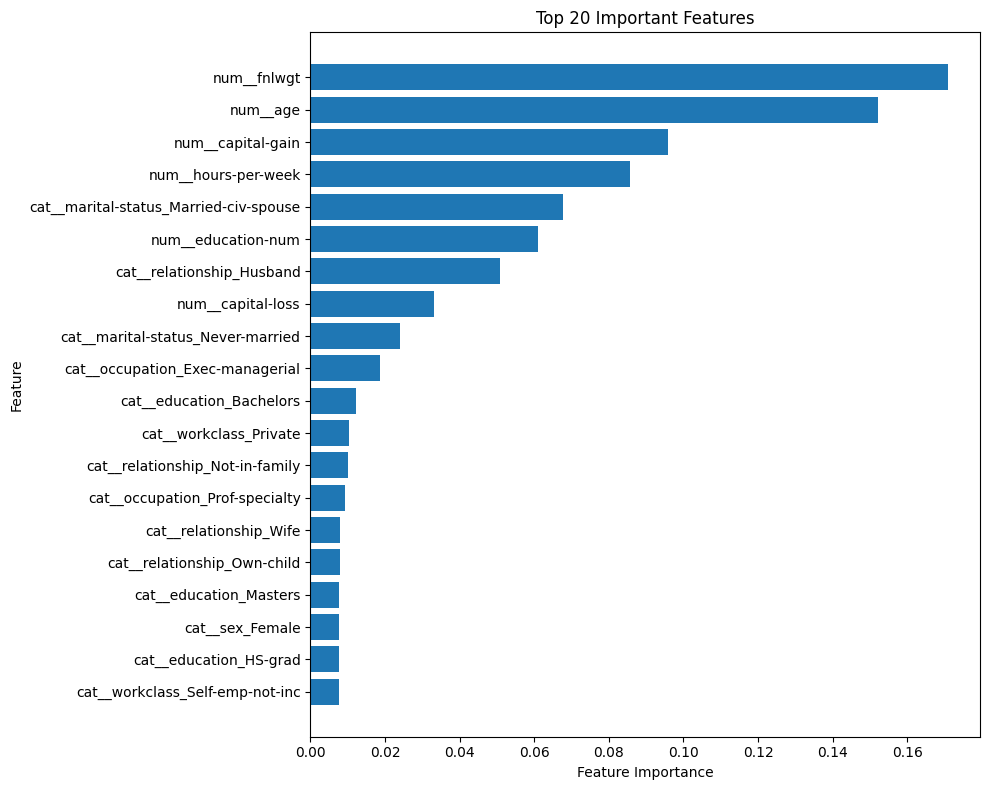

In [ ]:
# Select top 20 important features

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features")

plt.tight_layout()
plt.show()

In [ ]:
# Save feature importance results

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [ ]:
# Test the pipeline on a few unseen records

sample_data = X_test.iloc[:5]

sample_predictions = model_pipeline.predict(sample_data)

print("Predictions for sample records:")
print(sample_predictions)

Predictions for sample records:
['<=50K' '<=50K' '>50K' '<=50K' '>50K']


In [ ]:
# Project Summary

In this task, a complete and leak-free machine learning preprocessing
pipeline was developed using Scikit-Learn.

The project included:

- Loading a complex tabular dataset
- Identifying numerical and categorical features
- Splitting the dataset before preprocessing
- Handling missing numerical values using median imputation
- Handling missing categorical values using most-frequent imputation
- Scaling numerical features using StandardScaler
- Encoding categorical features using OneHotEncoder
- Combining transformations using ColumnTransformer
- Building a reusable Pipeline
- Training a Random Forest classification model
- Evaluating the model using accuracy and classification metrics
- Performing tree-based feature importance analysis
- Visualizing the most important features

The pipeline ensures that preprocessing is learned only from the
training data, thereby reducing the risk of data leakage.

In [ ]:
                 ADULT INCOME DATASET
                         |
                         ↓
                  Train/Test Split
                         |
             ┌───────────┴───────────┐
             ↓                       ↓
       Numerical Data          Categorical Data
             |                       |
          Imputer                  Imputer
         (Median)              (Most Frequent)
             |                       |
          Scaling               One-Hot Encoding
       StandardScaler                  |
             |                       |
             └───────────┬───────────┘
                         ↓
                  ColumnTransformer
                         ↓
                  Processed Dataset
                         ↓
                  Random Forest
                         ↓
                    Prediction
                         ↓
               Model Evaluation
                         ↓
              Feature Importance
                         ↓
                Visualization